Build visits once(reviews + tips + business coords)

In [1]:
import pandas as pd

users   = pd.read_csv("users_10k.csv")
reviews = pd.read_csv("reviews_10k.csv")
tips    = pd.read_csv("tips_10k.csv")
biz     = pd.read_csv("business_10k.csv")

# unify visits
reviews_ev = reviews[["user_id","business_id","date"]].copy()
reviews_ev["type"] = "review"

tips_ev = tips[["user_id","business_id","date"]].copy()
tips_ev["type"] = "tip"

visits = pd.concat([reviews_ev, tips_ev], ignore_index=True)

# attach lat/lon
visits = visits.merge(
    biz[["business_id","latitude","longitude"]],
    on="business_id",
    how="left"
).dropna(subset=["latitude","longitude"])

print("visits rows:", len(visits))
print("unique users:", visits["user_id"].nunique())

visits rows: 40440
unique users: 10000


Filter eligible users(visits >= 5)

In [2]:
MIN_VISITS = 5

user_counts = visits.groupby("user_id").size()
eligible_users = user_counts[user_counts >= MIN_VISITS].index

visits_elig = visits[visits["user_id"].isin(eligible_users)].copy()

print("eligible users:", len(eligible_users))
print("eligible visits:", len(visits_elig))

eligible users: 1680
eligible visits: 27164


DBSCAN function

In [3]:
import numpy as np
from sklearn.cluster import DBSCAN

def dbscan_labels_latlon(df, eps_km=2.0, min_samples=3):
    coords = np.radians(df[["latitude","longitude"]].values)
    db = DBSCAN(
        eps=eps_km / 6371.0,      # km -> radians
        min_samples=min_samples,
        metric="haversine"
    ).fit(coords)
    return db.labels_

Run DBSCAN for one user(for visualisation)

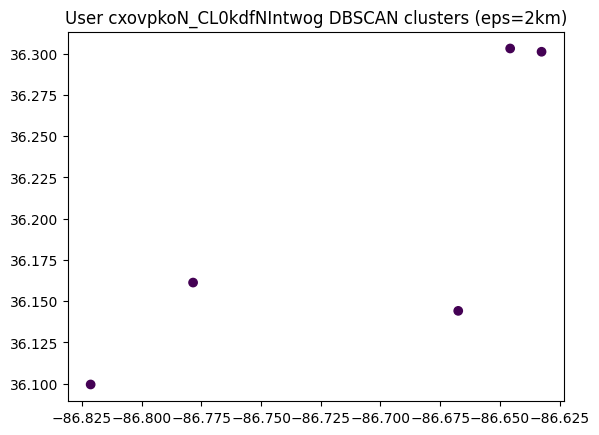

cluster
-1    5
Name: count, dtype: int64


In [4]:
import matplotlib.pyplot as plt

# pick a user with enough visits
uid = user_counts[user_counts >= MIN_VISITS].sample(1).index[0]
u = visits[visits["user_id"] == uid].copy()  # <-- copy fixes warning

u["cluster"] = dbscan_labels_latlon(u, eps_km=2.0, min_samples=3)

plt.scatter(u["longitude"], u["latitude"], c=u["cluster"])
plt.title(f"User {uid} DBSCAN clusters (eps=2km)")
plt.show()

print(u["cluster"].value_counts().sort_index())

Run DBSCAN for all eligible users

In [5]:
def count_centers(labels):
    return len(set(labels) - {-1})

stats = []

for uid, df in visits_elig.groupby("user_id"):
    labels = dbscan_labels_latlon(df, eps_km=2.0, min_samples=3)
    stats.append({
        "user_id": uid,
        "n_visits": len(df),
        "n_centers": count_centers(labels),
        "noise_ratio": float((labels == -1).sum() / len(labels)),
    })

cluster_df = pd.DataFrame(stats)

print(cluster_df["n_centers"].value_counts().sort_index())
cluster_df.head()

n_centers
0     529
1     747
2     225
3      80
4      37
5      20
6      14
7       8
8       6
9       5
10      1
11      2
12      1
13      1
16      1
17      1
20      1
26      1
Name: count, dtype: int64


,user_id,n_visits,n_centers,noise_ratio
0,-0A675r8EE26FmhYx68KHw,5,0,1.000000
1,-0MIp6WKJ8QvGnYZQ5ETyg,22,3,0.409091
2,-1VbC_BSr9ai4drsuCCJxA,7,1,0.428571
3,-6DoXmdXEy_P5N-QZzntgA,15,1,0.666667
4,-6cPEM5jtb6A2M6mggn47g,18,2,0.000000


Picking a good demo user

In [11]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import haversine_distances

def bbox_span_km(df):
    # quick “spread” proxy using bounding box corners
    lat_min, lat_max = df["latitude"].min(), df["latitude"].max()
    lon_min, lon_max = df["longitude"].min(), df["longitude"].max()
    corners = np.radians([[lat_min, lon_min], [lat_max, lon_max]])
    return float(haversine_distances(corners)[0,1] * 6371)

spans = []
for uid, df in visits_elig.groupby("user_id"):
    spans.append({"user_id": uid, "span_km": bbox_span_km(df)})

span_df = pd.DataFrame(spans)

# join onto your cluster_df (which already has n_centers, noise_ratio, n_visits)
demo_pool = (cluster_df
    .merge(span_df, on="user_id", how="left")
    .query("n_centers >= 2 and noise_ratio < 0.3 and span_km < 50")  # tune 50km if needed
)

print("demo candidates:", len(demo_pool))
demo_uid = demo_pool.sample(1)["user_id"].iloc[0]
demo_uid

demo candidates: 130


'UFq51LFmhfEPn21CM9l_RQ'

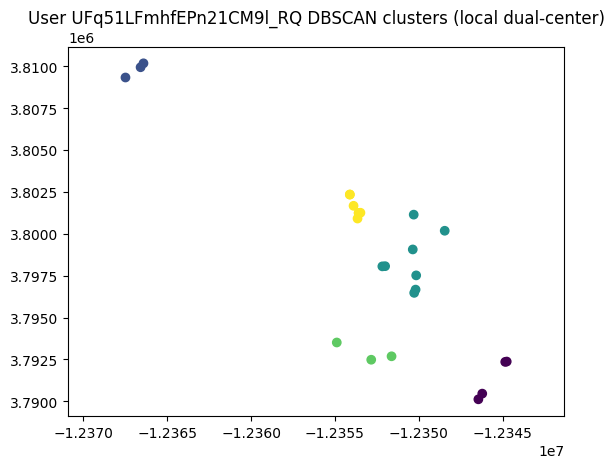

cluster
-1    5
 0    4
 1    3
 2    8
 3    3
 4    7
Name: count, dtype: int64


In [12]:
import matplotlib.pyplot as plt
from pyproj import Transformer

transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)

u = visits[visits["user_id"] == demo_uid].copy()
u["cluster"] = dbscan_labels_latlon(u, eps_km=2.0, min_samples=3)

x, y = transformer.transform(u["longitude"].values, u["latitude"].values)
u["x"], u["y"] = x, y

# plot WITHOUT noise so it looks clean
u_plot = u[u["cluster"] != -1].copy()

plt.scatter(u_plot["x"], u_plot["y"], c=u_plot["cluster"])
plt.axis("equal")
plt.title(f"User {demo_uid} DBSCAN clusters (local dual-center)")
plt.show()

print(u["cluster"].value_counts().sort_index())

In [7]:
def run_population(eps_km):
    stats = []
    for uid, df in visits_elig.groupby("user_id"):
        labels = dbscan_labels_latlon(df, eps_km=eps_km, min_samples=3)
        stats.append(len(set(labels) - {-1}))
    s = pd.Series(stats)
    return {
        "eps_km": eps_km,
        "pct_multi_center": float((s >= 2).mean()),
        "pct_any_center": float((s >= 1).mean()),
        "mean_centers": float(s.mean()),
    }

for eps in [1.0, 2.0, 3.0]:
    print(run_population(eps))

{'eps_km': 1.0, 'pct_multi_center': 0.2125, 'pct_any_center': 0.5476190476190477, 'mean_centers': 1.1357142857142857}
{'eps_km': 2.0, 'pct_multi_center': 0.24047619047619048, 'pct_any_center': 0.6851190476190476, 'mean_centers': 1.2226190476190477}
{'eps_km': 3.0, 'pct_multi_center': 0.24642857142857144, 'pct_any_center': 0.7708333333333334, 'mean_centers': 1.2291666666666667}


In [13]:
def avg_noise_ratio(eps_km):
    ratios = []
    for uid, df in visits_elig.groupby("user_id"):
        labels = dbscan_labels_latlon(df, eps_km=eps_km, min_samples=3)
        ratios.append((labels == -1).sum() / len(labels))
    return np.mean(ratios)

for eps in [0.5, 1, 2, 3, 5]:
    print(eps, avg_noise_ratio(eps))

0.5 0.7957283677380863
1 0.6931100004543703
2 0.5519264227544892
3 0.4544023619250006
5 0.31831299879726793


In [14]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import haversine_distances

def centroid_separation_km(df):
    centroids = df[df["cluster"] != -1].groupby("cluster")[["latitude","longitude"]].mean()
    if len(centroids) != 2:
        return None
    coords = np.radians(centroids.values)
    return float(haversine_distances(coords)[0,1] * 6371)

def two_center_separations(eps_km):
    seps = []
    for uid, df in visits_elig.groupby("user_id"):
        labels = dbscan_labels_latlon(df, eps_km=eps_km, min_samples=3)
        k = len(set(labels) - {-1})
        if k == 2:
            tmp = df.copy()
            tmp["cluster"] = labels
            d = centroid_separation_km(tmp)
            if d is not None:
                seps.append(d)
    return pd.Series(seps)

for eps in [1, 2, 3, 5]:
    s = two_center_separations(eps)
    if len(s) == 0:
        print("eps", eps, ": no 2-center users found")
        continue
    print("eps", eps,
          "| n:", len(s),
          "| median sep (km):", float(s.median()),
          "| 75%:", float(s.quantile(0.75)))

eps 1 | n: 191 | median sep (km): 5.464386489805821 | 75%: 17.23931831209763
eps 2 | n: 225 | median sep (km): 7.971499720058175 | 75%: 23.42619130995443
eps 3 | n: 250 | median sep (km): 10.891691957614874 | 75%: 24.1854170896926
eps 5 | n: 278 | median sep (km): 14.924073320682657 | 75%: 29.492037077501834


Fixing the DBSCAN parameter

In [15]:
EPS_KM = 2.0
MIN_SAMPLES = 3

stats = []

for uid, df in visits_elig.groupby("user_id"):
    labels = dbscan_labels_latlon(df, eps_km=EPS_KM, min_samples=MIN_SAMPLES)
    n_centers = len(set(labels) - {-1})
    noise_ratio = (labels == -1).sum() / len(labels)
    
    stats.append({
        "user_id": uid,
        "n_visits": len(df),
        "n_centers": n_centers,
        "noise_ratio": noise_ratio
    })

final_df = pd.DataFrame(stats)
final_df.head()

,user_id,n_visits,n_centers,noise_ratio
0,-0A675r8EE26FmhYx68KHw,5,0,1.000000
1,-0MIp6WKJ8QvGnYZQ5ETyg,22,3,0.409091
2,-1VbC_BSr9ai4drsuCCJxA,7,1,0.428571
3,-6DoXmdXEy_P5N-QZzntgA,15,1,0.666667
4,-6cPEM5jtb6A2M6mggn47g,18,2,0.000000


In [16]:
final_df.to_csv("user_activity_centers_eps2km.csv", index=False)

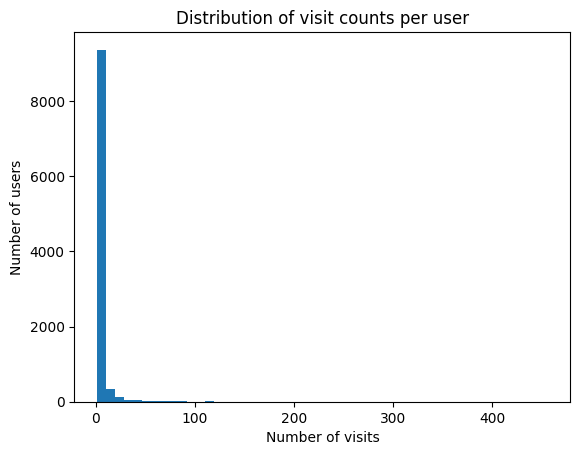

In [17]:
user_counts = visits.groupby("user_id").size()

plt.hist(user_counts, bins=50)
plt.xlabel("Number of visits")
plt.ylabel("Number of users")
plt.title("Distribution of visit counts per user")
plt.show()

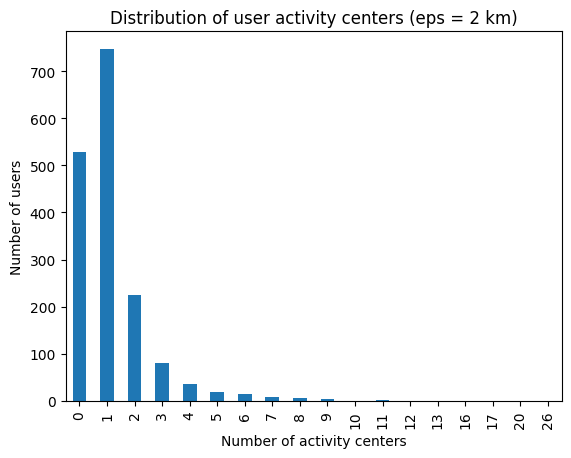

In [18]:
final_df["n_centers"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Number of activity centers")
plt.ylabel("Number of users")
plt.title("Distribution of user activity centers (eps = 2 km)")
plt.show()

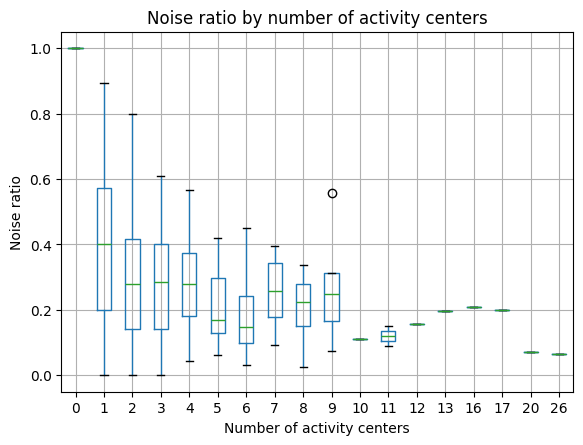

In [19]:
final_df.boxplot(column="noise_ratio", by="n_centers")
plt.suptitle("")
plt.xlabel("Number of activity centers")
plt.ylabel("Noise ratio")
plt.title("Noise ratio by number of activity centers")
plt.show()

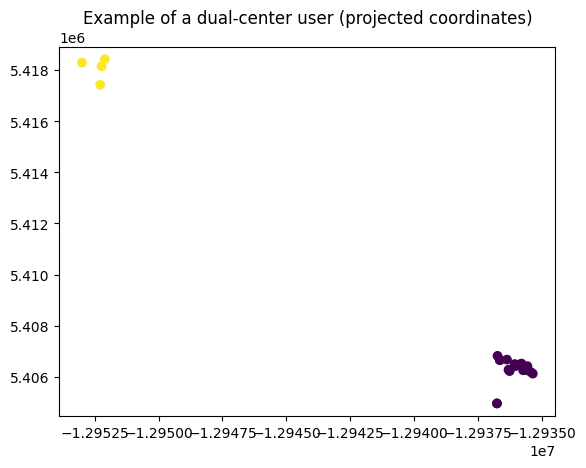

In [20]:
demo_uid = (
    final_df
    .merge(span_df, on="user_id")
    .query("n_centers == 2 and noise_ratio < 0.3 and span_km < 50")
    .sample(1)["user_id"]
    .iloc[0]
)

u = visits[visits["user_id"] == demo_uid].copy()
u["cluster"] = dbscan_labels_latlon(u, eps_km=2.0, min_samples=3)

x, y = transformer.transform(u["longitude"].values, u["latitude"].values)
u["x"], u["y"] = x, y

u_plot = u[u["cluster"] != -1]

plt.scatter(u_plot["x"], u_plot["y"], c=u_plot["cluster"])
plt.axis("equal")
plt.title("Example of a dual-center user (projected coordinates)")
plt.show()